# Gradient Descent: What Happens Behind the Model API

This is an **educational interview reference**, not the production training path.
It uses one feature from the training partition to make the cost surface visible
and to connect the slope, learning rate, cost bowl and contour plot. The production
model is evidence-selected histogram gradient boosting; scikit-learn's ordinary
linear-regression solver also does not call this manual loop.

Only the 331 training rows are used. The protected holdout is not opened here.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

from house_prices import config
from house_prices.data import load_dataset
from house_prices.train import split_data

df = load_dataset()
X_train, _, y_train, _ = split_data(df)
x_raw = np.log10(X_train["mrt_distance_m"].to_numpy())
x_mean, x_std = x_raw.mean(), x_raw.std()
x = (x_raw - x_mean) / x_std
y = y_train.to_numpy()
print(f"Educational fit: {len(x)} training rows; protected holdout untouched")

Educational fit: 331 training rows; protected holdout untouched


## The calculation

For one standardized input, the prediction is $\hat{y}=wx+b$. The cost is
$J(w,b)=\frac{1}{2m}\sum(\hat{y}-y)^2$. Its partial derivatives are
$\frac{\partial J}{\partial w}=\frac{1}{m}\sum(\hat{y}-y)x$ and
$\frac{\partial J}{\partial b}=\frac{1}{m}\sum(\hat{y}-y)$.

The gradient is the local uphill direction, so gradient descent subtracts it.
The learning rate $\alpha$ controls the step size. Both parameters are updated
simultaneously from the same old values.

In [2]:
def compute_cost(x, y, w, b):
    errors = w * x + b - y
    return float(np.mean(errors**2) / 2)


def compute_gradient(x, y, w, b):
    errors = w * x + b - y
    return float(np.mean(errors * x)), float(np.mean(errors))


def gradient_descent(x, y, alpha, iterations, w=0.0, b=0.0):
    history = []
    for step in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w_next = w - alpha * dj_dw
        b_next = b - alpha * dj_db
        w, b = w_next, b_next
        history.append((step + 1, w, b, compute_cost(x, y, w, b)))
    return w, b, np.asarray(history)


w_gd, b_gd, good_path = gradient_descent(x, y, alpha=0.05, iterations=250)
_, _, slow_path = gradient_descent(x, y, alpha=0.005, iterations=250)
_, _, large_path = gradient_descent(x, y, alpha=2.10, iterations=30)

closed_form = LinearRegression().fit(x.reshape(-1, 1), y)
print(f"manual GD:       w={w_gd:.4f}, b={b_gd:.4f}, cost={good_path[-1, 3]:.4f}")
print(f"sklearn optimum: w={closed_form.coef_[0]:.4f}, b={closed_form.intercept_:.4f}")
print(f"first gradient:  dJ/dw={compute_gradient(x, y, 0.0, 0.0)[0]:.4f}, "
      f"dJ/db={compute_gradient(x, y, 0.0, 0.0)[1]:.4f}")

manual GD:       w=-9.2234, b=37.6697, cost=40.7545
sklearn optimum: w=-9.2234, b=37.6698
first gradient:  dJ/dw=9.2234, dJ/db=-37.6698


Standardizing the input makes the two directions of the bowl similarly scaled,
so one learning rate can move efficiently in both. Scaling does not change the
underlying linear relationship; it changes the numerical route to the optimum.

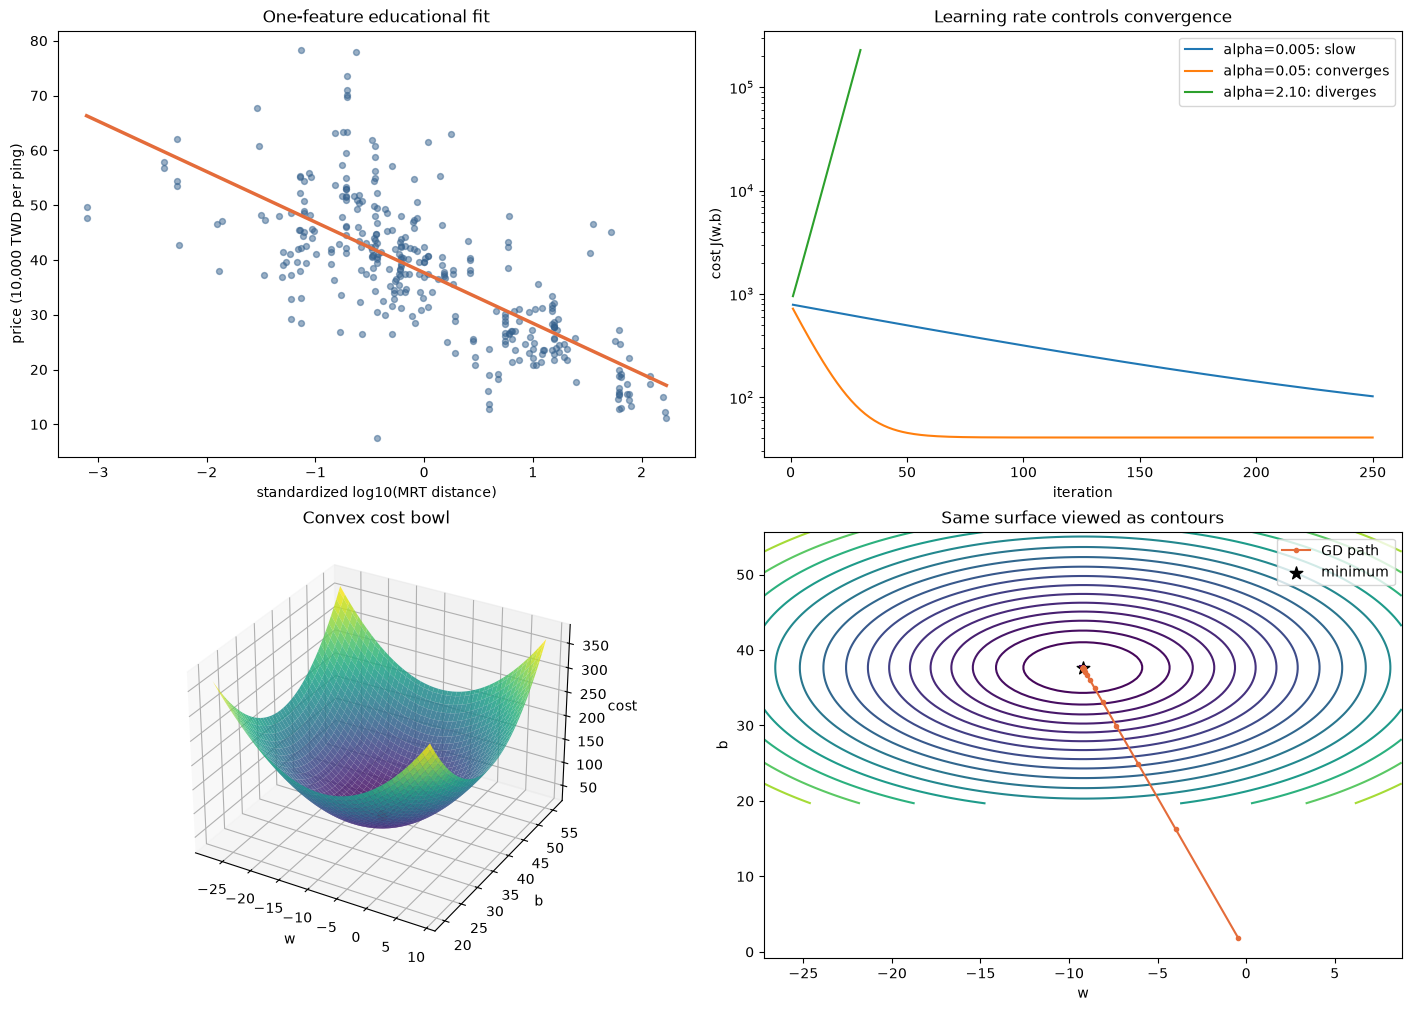

saved D:\Learning\Supervised Machine - Learning Regression and Classification\Labs\Use_case\house-price-predictor\docs\figures\gradient_descent_reference.png


In [3]:
w_star = float(closed_form.coef_[0])
b_star = float(closed_form.intercept_)
w_grid = np.linspace(w_star - 18, w_star + 18, 90)
b_grid = np.linspace(b_star - 18, b_star + 18, 90)
W, B = np.meshgrid(w_grid, b_grid)
J = np.array([[compute_cost(x, y, w, b) for w in w_grid] for b in b_grid])

fig = plt.figure(figsize=(14, 10), constrained_layout=True)
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(x, y, s=18, alpha=0.5, color="#35618d")
x_line = np.linspace(x.min(), x.max(), 100)
ax1.plot(x_line, w_gd * x_line + b_gd, color="#e46c3a", linewidth=2.5)
ax1.set(title="One-feature educational fit", xlabel="standardized log10(MRT distance)",
        ylabel="price (10,000 TWD per ping)")

ax2 = fig.add_subplot(2, 2, 2)
ax2.semilogy(slow_path[:, 0], slow_path[:, 3], label="alpha=0.005: slow")
ax2.semilogy(good_path[:, 0], good_path[:, 3], label="alpha=0.05: converges")
ax2.semilogy(large_path[:, 0], large_path[:, 3], label="alpha=2.10: diverges")
ax2.set(title="Learning rate controls convergence", xlabel="iteration", ylabel="cost J(w,b)")
ax2.legend()

ax3 = fig.add_subplot(2, 2, 3, projection="3d")
ax3.plot_surface(W, B, J, cmap="viridis", alpha=0.85, linewidth=0)
ax3.scatter([w_star], [b_star], [compute_cost(x, y, w_star, b_star)],
            color="#e46c3a", s=45, label="minimum")
ax3.set(title="Convex cost bowl", xlabel="w", ylabel="b", zlabel="cost")

ax4 = fig.add_subplot(2, 2, 4)
levels = np.geomspace(max(J.min(), 1e-3), J.max(), 18)
ax4.contour(W, B, J, levels=levels, cmap="viridis")
path = good_path[::10]
ax4.plot(path[:, 1], path[:, 2], "o-", color="#e46c3a", markersize=3, label="GD path")
ax4.scatter([w_star], [b_star], color="black", marker="*", s=90, label="minimum")
ax4.set(title="Same surface viewed as contours", xlabel="w", ylabel="b")
ax4.legend()

figure_path = config.REPORTS_DIR / "gradient_descent_reference.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"saved {figure_path}")

## A concise interview explanation

1. Start with guesses for $w$ and $b$ and calculate prediction errors.
2. The partial derivatives say how steeply cost rises in each parameter direction.
3. Subtract $\alpha$ times those slopes, updating $w$ and $b$ together.
4. A small learning rate converges slowly; a suitable one descends steadily; an
   excessive one overshoots the valley and diverges.
5. Because squared-error linear regression is a convex bowl, reaching its bottom
   gives the global optimum; the agreement with scikit-learn is a useful check.

This demonstrates the optimization concept behind the course material without
claiming that manual gradient descent trained the deployed tree ensemble.